In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CKD Project/kidney_disease.csv")
df.sample(10)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
118,55.0,70.0,1.010,3.0,0.0,NaN,normal,notpresent,notpresent,99.0,...,NaN,NaN,NaN,no,no,no,poor,yes,no,ckd
378,71.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,NaN,...,42.0,7700.0,5.5,no,no,no,good,no,no,notckd
139,41.0,70.0,1.015,2.0,0.0,NaN,abnormal,notpresent,present,NaN,...,33.0,NaN,NaN,yes,no,no,good,yes,yes,ckd
312,80.0,70.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,NaN,...,48.0,6300.0,6.1,no,no,no,good,no,no,notckd
105,65.0,80.0,1.015,0.0,0.0,NaN,normal,notpresent,notpresent,115.0,...,42.0,6800.0,5.2,no,no,no,good,no,no,ckd
344,64.0,60.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,106.0,...,42.0,8100.0,4.7,no,no,no,good,no,no,notckd
383,80.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,119.0,...,49.0,5100.0,5.0,no,no,no,good,no,no,notckd
283,60.0,70.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,NaN,...,43.0,10800.0,5.7,no,no,no,good,no,no,notckd
138,73.0,NaN,1.010,1.0,0.0,NaN,NaN,notpresent,notpresent,95.0,...,NaN,NaN,NaN,no,no,no,good,no,no,ckd
189,64.0,60.0,1.010,4.0,1.0,abnormal,abnormal,notpresent,present,239.0,...,29.0,7500.0,3.4,yes,yes,no,poor,yes,no,ckd


In [58]:
print(df.columns.to_list())

['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


In [59]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

Some of the numeric Features are forced to be float for example (age, etc) that can never be float

In [60]:
print(df.describe())

              age          bp          sg          al          su         bgr  \
count  391.000000  388.000000  353.000000  354.000000  351.000000  356.000000   
mean    51.483376   76.469072    1.017408    1.016949    0.450142  148.036517   
std     17.169714   13.683637    0.005717    1.352679    1.099191   79.281714   
min      2.000000   50.000000    1.005000    0.000000    0.000000   22.000000   
25%     42.000000   70.000000    1.010000    0.000000    0.000000   99.000000   
50%     55.000000   80.000000    1.020000    0.000000    0.000000  121.000000   
75%     64.500000   80.000000    1.020000    2.000000    0.000000  163.000000   
max     90.000000  180.000000    1.025000    5.000000    5.000000  490.000000   

               bu          sc         sod         pot        hemo         pcv  \
count  381.000000  383.000000  313.000000  312.000000  348.000000  329.000000   
mean    57.425722    3.072454  137.528754    4.627244   12.526437   38.884498   
std     50.503006    5.7411

In [61]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Missing Values:\n{missing}")

Missing Values:
rbc      152
rbcc     131
wbcc     106
pot       88
sod       87
pcv       71
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


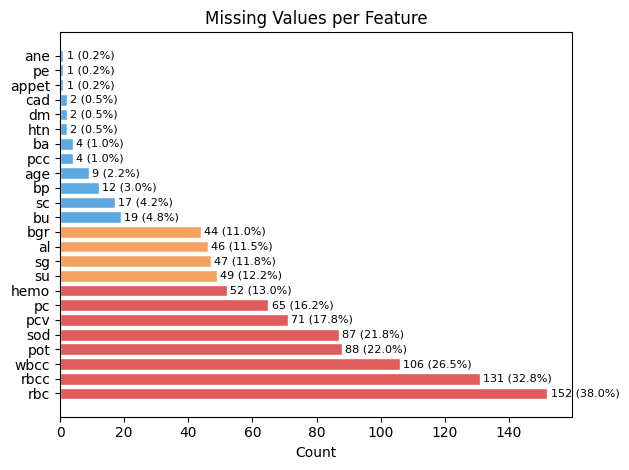

In [62]:
plt.barh(missing.index, missing.values,
         color=['#E05C5C' if v>50 else '#F4A261' if v>20 else '#5CA8E0' for v in missing],
         edgecolor='white')

[plt.text(v+1, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=8) for i, v in enumerate(missing)]

plt.title('Missing Values per Feature')
plt.xlabel('Count')
plt.tight_layout()

In [63]:
print("Duplicated Rows:\n",df.duplicated().sum())

Duplicated Rows:
 0


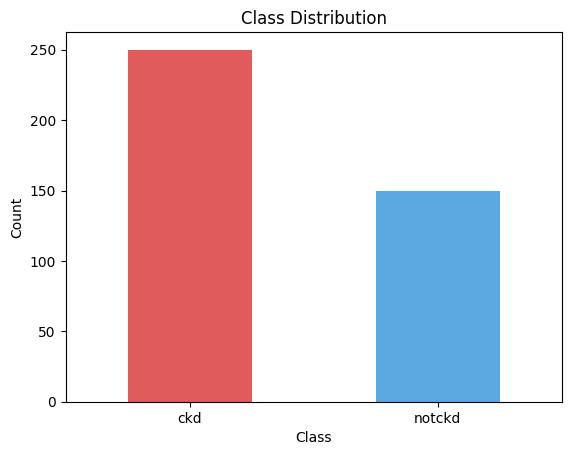

In [64]:
class_count = df['class'].value_counts()
class_count.plot(kind='bar',color=['#E05C5C','#5CA8E0'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [67]:
numerical_col = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']

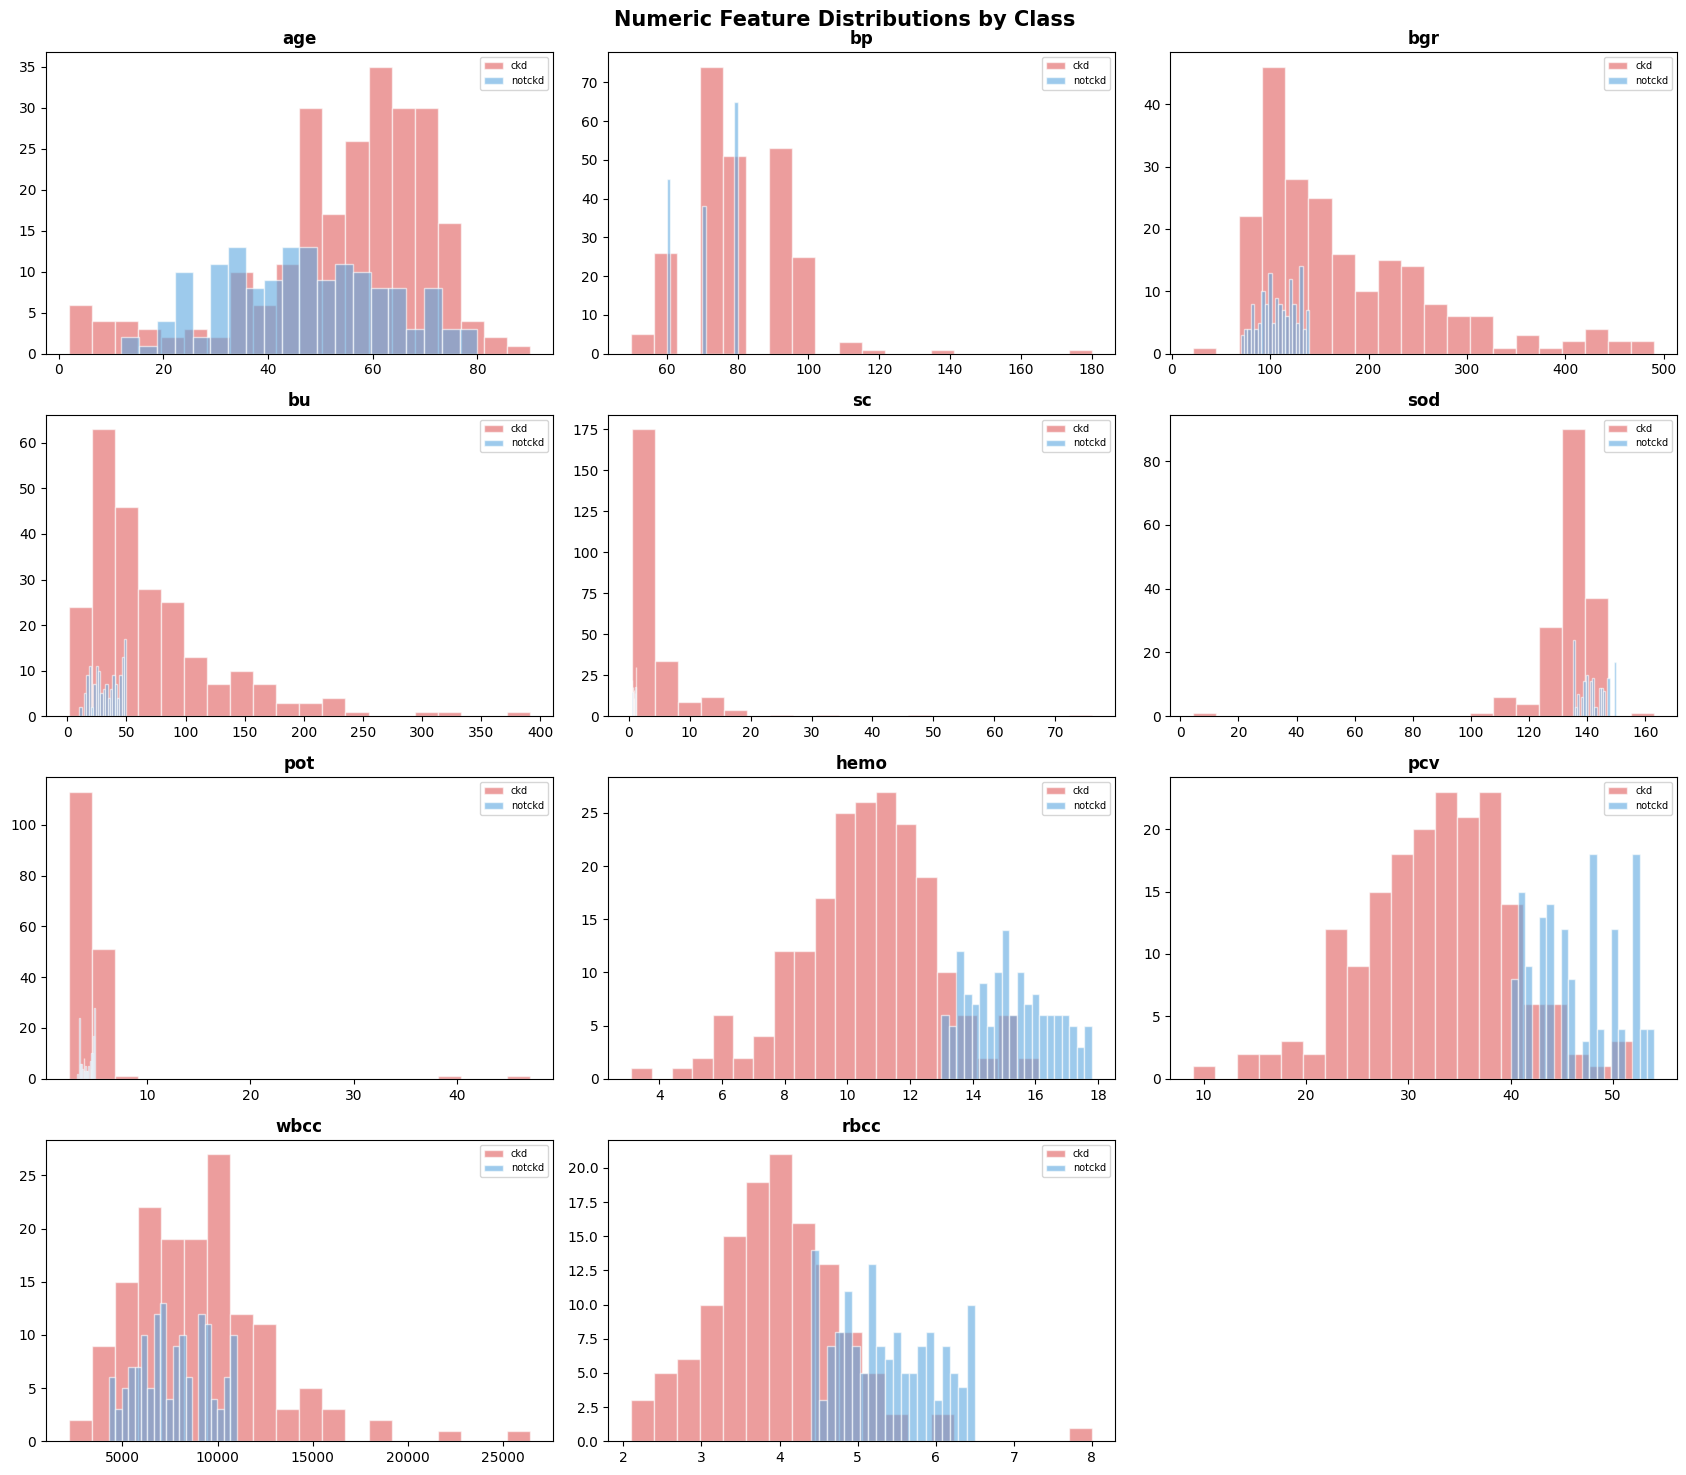

In [68]:
fig, axes = plt.subplots(4, 3, figsize=(17, 15))
axes = axes.flatten()

fig.suptitle('Numeric Feature Distributions by Class', fontsize=15, fontweight='bold')

classes = df['class'].unique()
colors = ['#E05C5C', '#5CA8E0']

for i, col in enumerate(numerical_col):
    ax = axes[i]

    for j, cls in enumerate(classes):
        subset = df[df['class'] == cls][col]
        ax.hist(subset, bins=20, alpha=0.6, label=cls, color=colors[j % len(colors)], edgecolor='white')

    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params()

for j in range(len(numerical_col), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

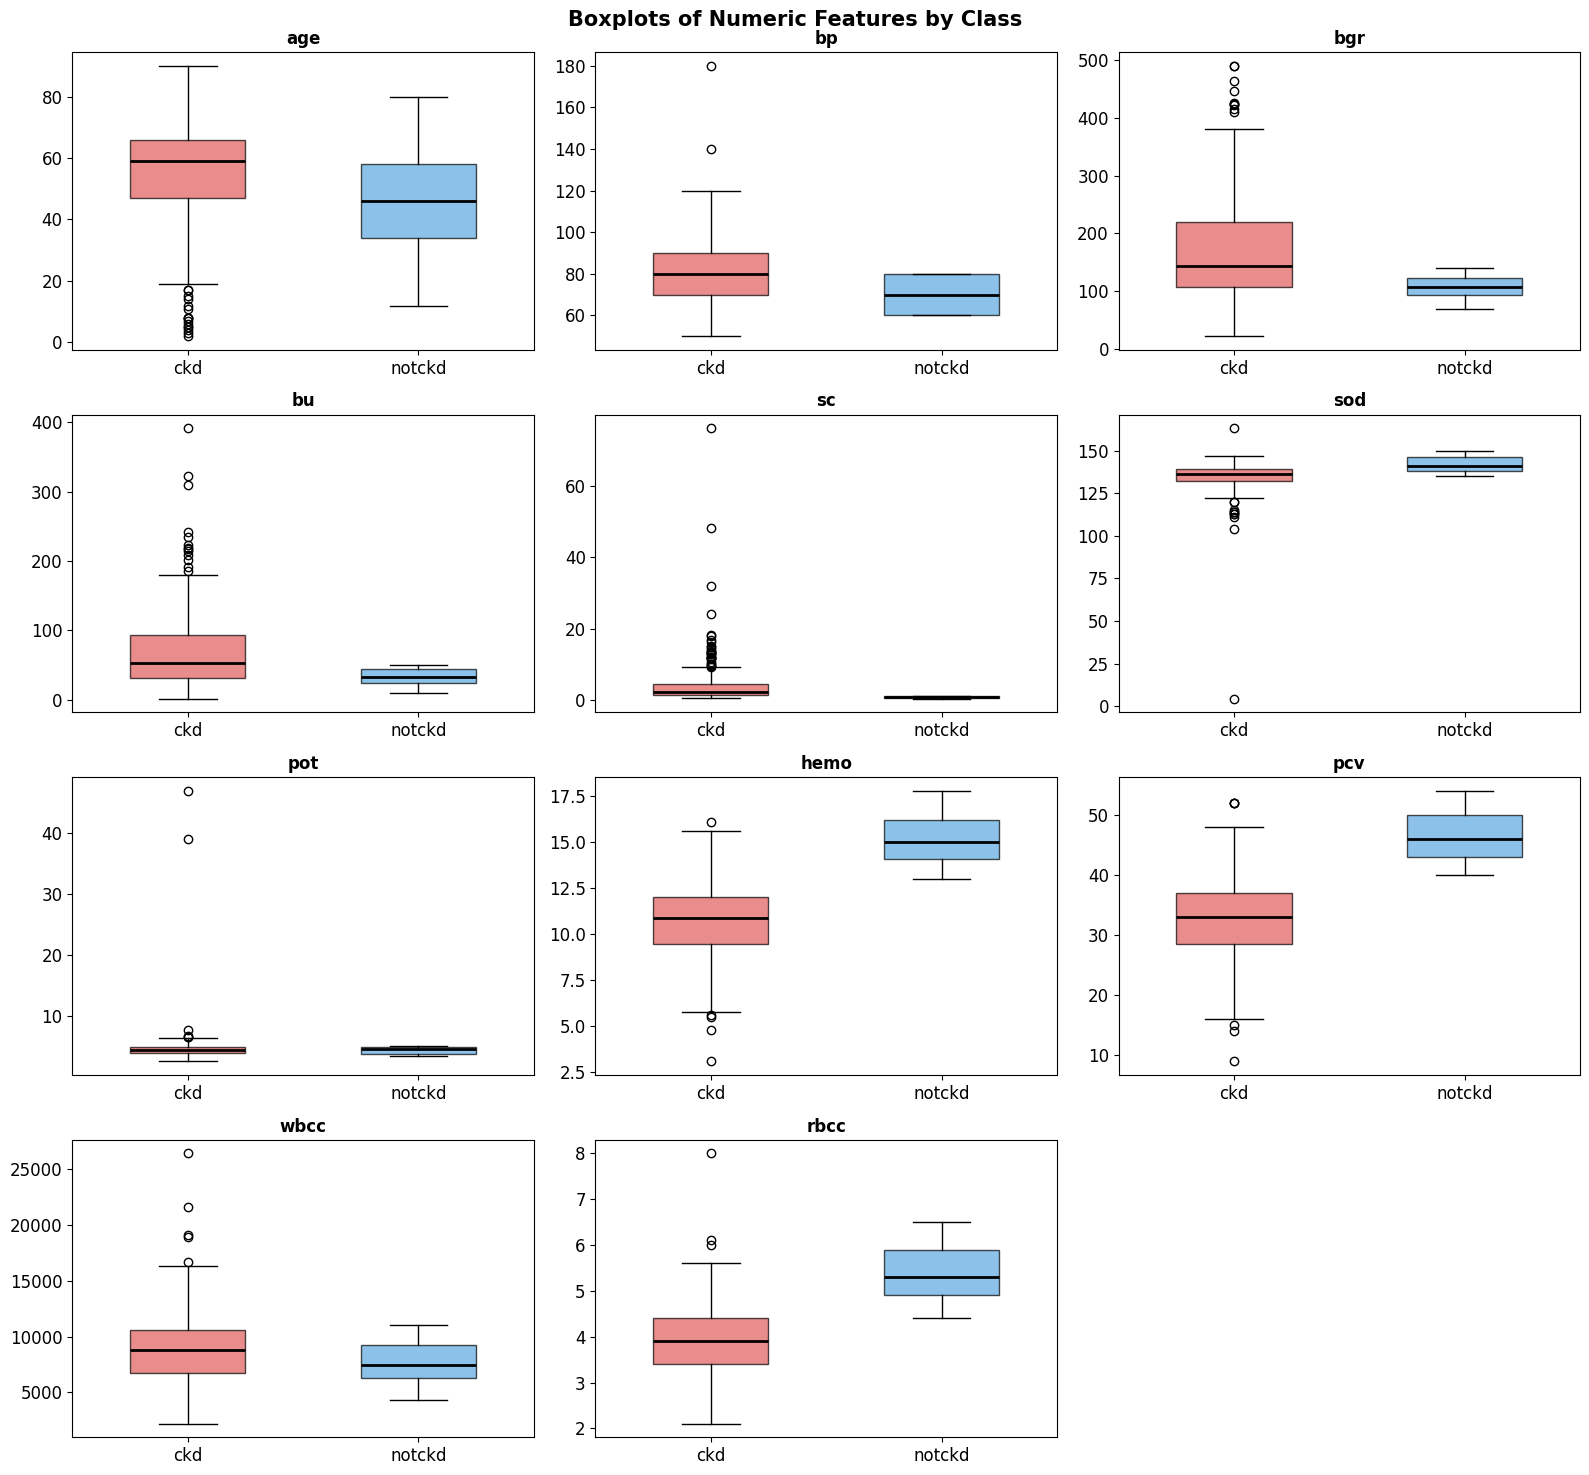

In [69]:
fig, axes = plt.subplots(4, 3, figsize=(16, 15))
axes = axes.flatten()

fig.suptitle('Boxplots of Numeric Features by Class', fontsize=15, fontweight='bold')

classes = df['class'].unique()
colors = ['#E05C5C', '#5CA8E0']

for i, col in enumerate(numerical_col):
    ax = axes[i]

    data = [df[df['class'] == cls][col].dropna() for cls in classes]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=classes, widths=0.5)

    for j, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[j % len(colors)])
        box.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(col, fontweight='bold')
    ax.tick_params(labelsize=12)

# Hide extra plots
for j in range(len(numerical_col), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

In [70]:
categorical_col = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane', 'su', 'al','sg']

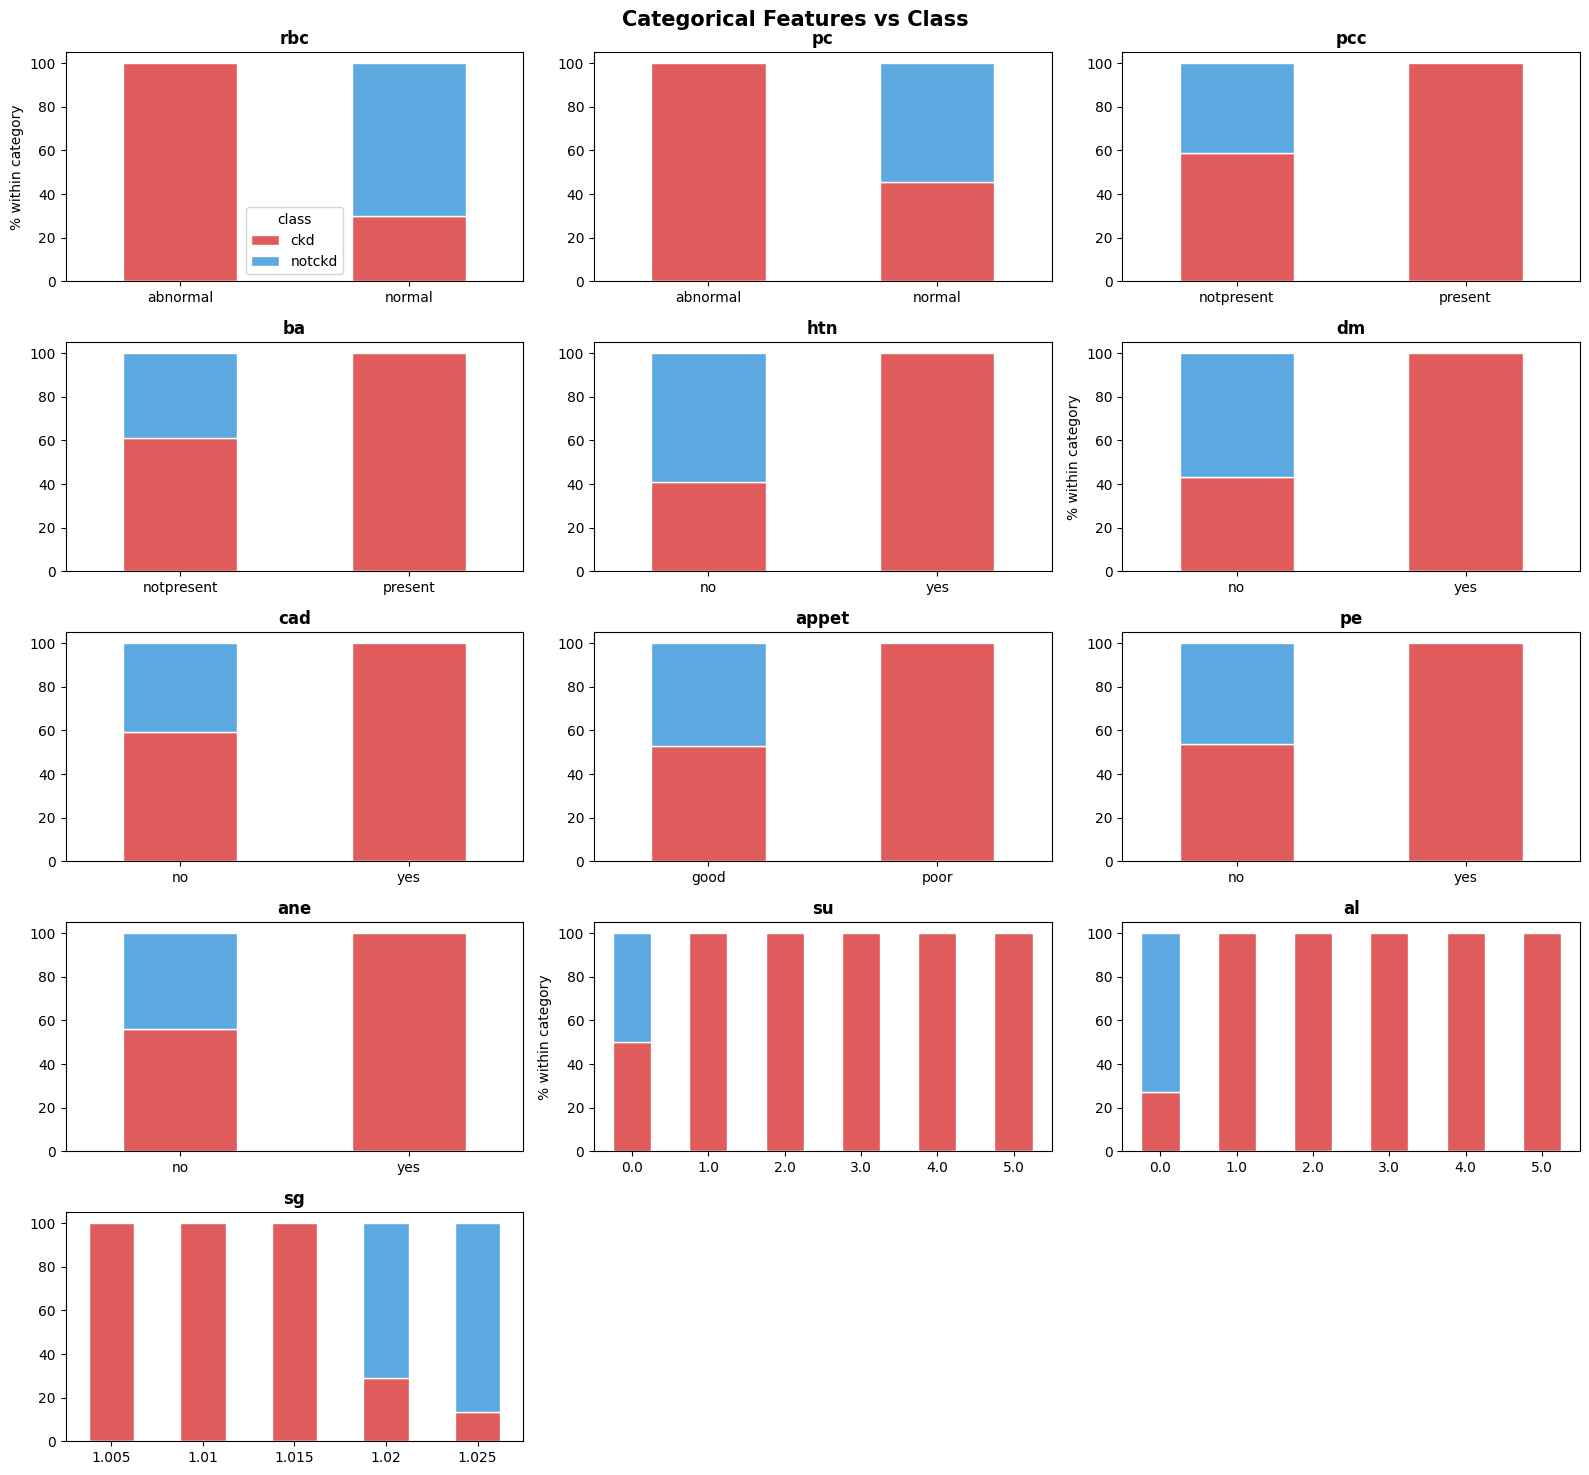

In [71]:
fig, axes = plt.subplots(5, 3, figsize=(16, 15))
axes = axes.flatten()

fig.suptitle('Categorical Features vs Class', fontsize=15, fontweight='bold')

classes = df['class'].unique()
colors = ['#E05C5C', '#5CA8E0']

# Exclude 'class' column from categorical_col for plotting
categorical_features_for_plot = [col for col in categorical_col if col != 'class']

for i, col in enumerate(categorical_features_for_plot):
    ax = axes[i]

    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    ct = ct[classes] if set(classes).issubset(ct.columns) else ct

    ct.plot(kind='bar', stacked=True, ax=ax,
            color=colors[:len(ct.columns)],
            edgecolor='white', legend=(i == 0))

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% within category' if i % 5 == 0 else '')
    ax.tick_params(axis='x', rotation=0)

# Hide extra plots
# The range should now be based on categorical_features_for_plot length
for j in range(len(categorical_features_for_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

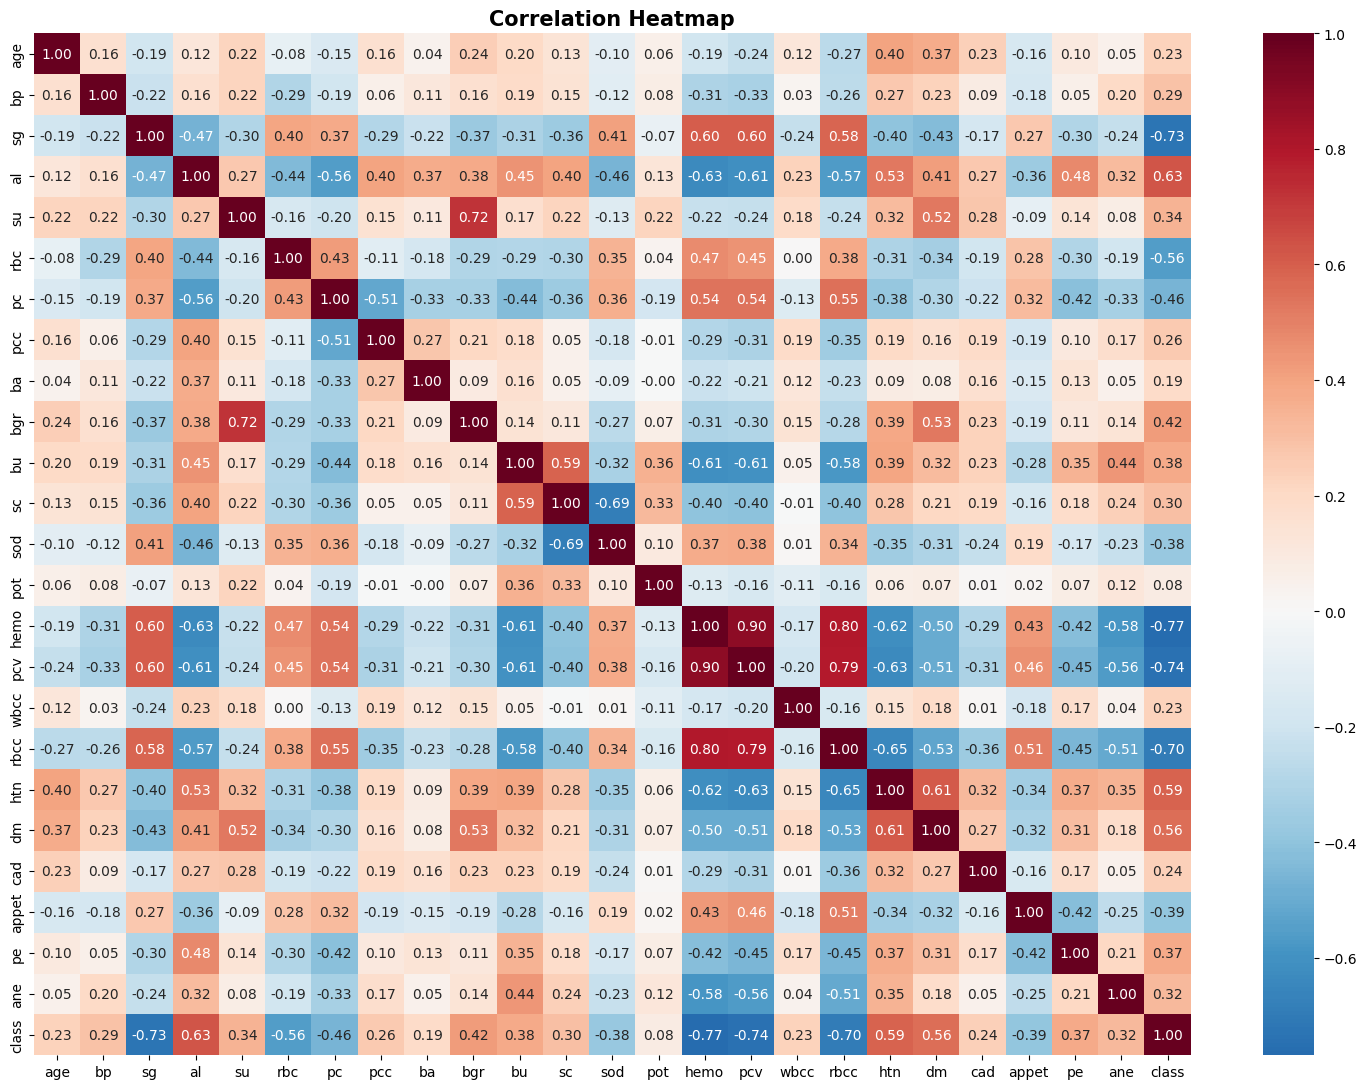

In [72]:
# Correlation Heatmap
CAT_COLS = df.select_dtypes(include=['object']).columns.tolist()
binary_map = {'yes':1,'no':0,'normal':1,'abnormal':0, 'present':1,'notpresent':0,'good':1,'poor':0, 'ckd':1, 'notckd':0}
for col in CAT_COLS:
    df[col] = df[col].map(binary_map)

plt.figure(figsize=(15, 11))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [73]:
target_correlations = corr['class'].sort_values(ascending=False)
print(target_correlations)

class    1.000000
al       0.627090
htn      0.588820
dm       0.557444
bgr      0.419672
bu       0.380605
pe       0.374480
su       0.344070
ane      0.324787
sc       0.299969
bp       0.294077
pcc      0.263226
cad      0.235153
wbcc     0.231919
age      0.227268
ba       0.185345
pot      0.084541
sod     -0.375674
appet   -0.392645
pc      -0.461812
rbc     -0.555097
rbcc    -0.699089
sg      -0.732163
pcv     -0.741427
hemo    -0.768919
Name: class, dtype: float64


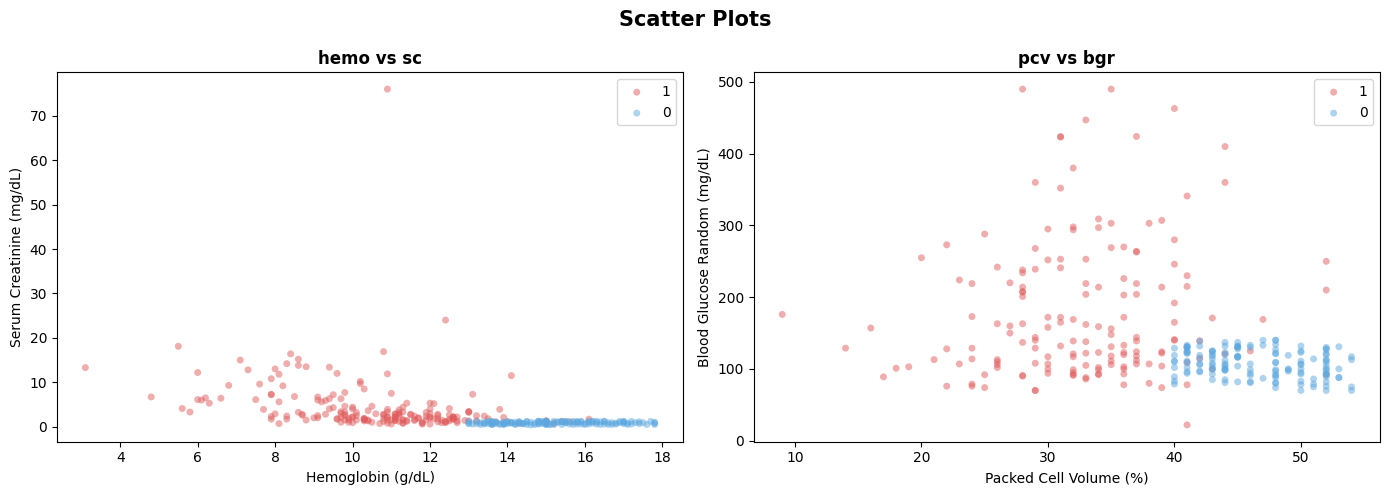

In [74]:
# Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter Plots', fontsize=15, fontweight='bold')

pairs  = [('hemo', 'sc'),  ('pcv', 'bgr')]
labels = [('Hemoglobin (g/dL)', 'Serum Creatinine (mg/dL)'),
          ('Packed Cell Volume (%)', 'Blood Glucose Random (mg/dL)')]

classes = df['class'].unique()
colors = ['#E05C5C', '#5CA8E0']
PALETTE = {cls: color for cls, color in zip(classes, colors)}

for ax, (x, y), (xl, yl) in zip(axes, pairs, labels):
    for cls, color in PALETTE.items():
        sub = df[df['class'] == cls]
        ax.scatter(sub[x], sub[y], c=color, label=cls, alpha=0.5, s=25,
                   edgecolors='none')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend()

plt.tight_layout()